# QG ML Emulator - Ensemble PV Distribution Analysis

**Objective:** Analyze and compare Potential Vorticity (PV) distributions between:
- 2-layer QG Model (ground truth)
- ML Emulator (trained model)

**Dataset:**
- 1000 ensemble members
- Initialized identically through MLGETKF cycle
- Run for 3 hours (background ensemble)
- Grid: 64x64, 2 layers
- Variable: Potential Vorticity (PV)

## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from netCDF4 import Dataset
import warnings

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

Matplotlib is building the font cache; this may take a moment.


Librerías importadas exitosamente


## 2. Load and Explore Data

In [ ]:
# Load netCDF file
nc_path = "./Prediction_Target_ens1000.nc"
nc_file = Dataset(nc_path)

# Extract main variables
pv_qg = nc_file.variables['target_pv'][:]        # QG model: [ens, nz, ny, nx]
pv_ml = nc_file.variables['predicted_pv'][:]     # ML emulator: [ens, nz, ny, nx]

print("✓ Data loaded successfully")
print(f"\nData shapes:")
print(f"  PV QG model: {pv_qg.shape}")
print(f"  PV ML emulator: {pv_ml.shape}")
print(f"\nDimensions:")
print(f"  Ensemble members: {pv_qg.shape[0]}")
print(f"  Vertical layers: {pv_qg.shape[1]}")
print(f"  Spatial grid: {pv_qg.shape[2]}x{pv_qg.shape[3]}")

✓ Datos cargados exitosamente

Shape de datos:
  PV QG model: (1000, 2, 64, 64)
  PV ML emulator: (1000, 2, 64, 64)

Dimensiones:
  Ensemble members: 1000
  Capas verticales: 2
  Grilla espacial: 64x64


## 3. Visualize PV Fields

Display the spatial structure of Potential Vorticity from both QG model and ML emulator at different ensemble members and layers.

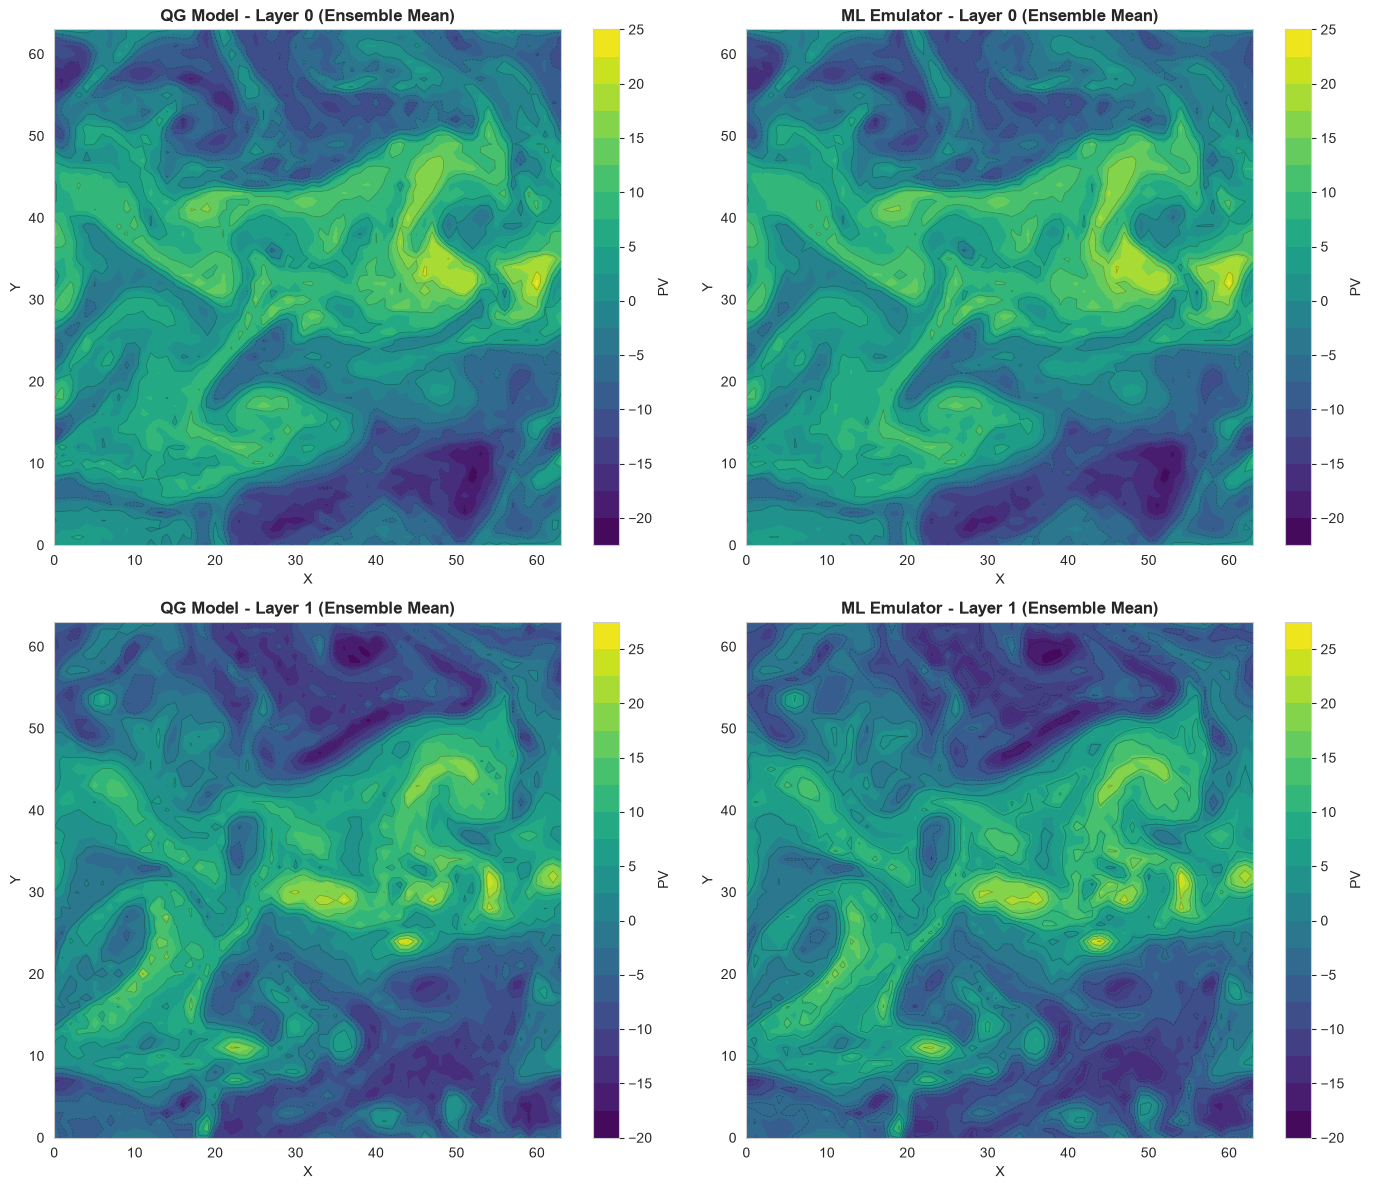

✓ Saved: pv_fields_ensemble_mean.png


In [3]:
# Plot ensemble mean PV fields for both layers
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Compute ensemble means
pv_qg_mean_l0 = np.mean(pv_qg[:, 0, :, :], axis=0)
pv_ml_mean_l0 = np.mean(pv_ml[:, 0, :, :], axis=0)
pv_qg_mean_l1 = np.mean(pv_qg[:, 1, :, :], axis=0)
pv_ml_mean_l1 = np.mean(pv_ml[:, 1, :, :], axis=0)

# Layer 0 - QG Model
im1 = axes[0, 0].contourf(pv_qg_mean_l0, levels=20, cmap='viridis')
axes[0, 0].contour(pv_qg_mean_l0, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[0, 0].set_title('QG Model - Layer 0 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
cbar1 = plt.colorbar(im1, ax=axes[0, 0])
cbar1.set_label('PV')

# Layer 0 - ML Emulator
im2 = axes[0, 1].contourf(pv_ml_mean_l0, levels=20, cmap='viridis')
axes[0, 1].contour(pv_ml_mean_l0, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[0, 1].set_title('ML Emulator - Layer 0 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')
cbar2 = plt.colorbar(im2, ax=axes[0, 1])
cbar2.set_label('PV')

# Layer 1 - QG Model
im3 = axes[1, 0].contourf(pv_qg_mean_l1, levels=20, cmap='viridis')
axes[1, 0].contour(pv_qg_mean_l1, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[1, 0].set_title('QG Model - Layer 1 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
cbar3 = plt.colorbar(im3, ax=axes[1, 0])
cbar3.set_label('PV')

# Layer 1 - ML Emulator
im4 = axes[1, 1].contourf(pv_ml_mean_l1, levels=20, cmap='viridis')
axes[1, 1].contour(pv_ml_mean_l1, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[1, 1].set_title('ML Emulator - Layer 1 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
cbar4 = plt.colorbar(im4, ax=axes[1, 1])
cbar4.set_label('PV')

plt.tight_layout()
plt.savefig('pv_fields_ensemble_mean.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: pv_fields_ensemble_mean.png")

## 4. Basic Statistics

In [4]:
# Basic statistics
print("=" * 60)
print("STATISTICS - QG MODEL (GROUND TRUTH)")
print("=" * 60)
print(f"Mean:       {np.mean(pv_qg):12.8f}")
print(f"Std Dev:    {np.std(pv_qg):12.8f}")
print(f"Minimum:    {np.min(pv_qg):12.8f}")
print(f"Maximum:    {np.max(pv_qg):12.8f}")
print(f"Median:     {np.median(pv_qg):12.8f}")

print("\n" + "=" * 60)
print("STATISTICS - ML EMULATOR")
print("=" * 60)
print(f"Mean:       {np.mean(pv_ml):12.8f}")
print(f"Std Dev:    {np.std(pv_ml):12.8f}")
print(f"Minimum:    {np.min(pv_ml):12.8f}")
print(f"Maximum:    {np.max(pv_ml):12.8f}")
print(f"Median:     {np.median(pv_ml):12.8f}")

print("\n" + "=" * 60)
print("DIFFERENCES (ML - QG)")
print("=" * 60)
diff = pv_ml - pv_qg
print(f"Mean error:  {np.mean(np.abs(diff)):12.8f}")
print(f"RMSE:        {np.sqrt(np.mean(diff**2)):12.8f}")
print(f"Max error:   {np.max(np.abs(diff)):12.8f}")

STATISTICS - QG MODEL (GROUND TRUTH)
Mean:        -0.01841136
Std Dev:      8.28531361
Minimum:    -26.76558304
Maximum:     35.34888458
Median:      -0.01241100

STATISTICS - ML EMULATOR
Mean:        -0.01020110
Std Dev:      8.23667526
Minimum:    -26.40765953
Maximum:     30.44390106
Median:      -0.01320564

DIFFERENCES (ML - QG)
Mean error:    0.61956177
RMSE:          0.80783303
Max error:     8.05685425


/Users/diegocarrio/Dropbox/Mac/Documents/Case_Studies/Xuguang_Collaboration/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


## 5. Normality Analysis at Various Grid Points

We will analyze whether the ensemble distributions are Gaussian or not at different grid points:
- **Central points**: Typically smoother
- **Points with gradients**: Expected to be more non-Gaussian
- **Nearby points**: We combine several points to increase ensemble data

In [5]:
def analyze_normality(data, layer, y, x, window_size=0):
    """
    Analyze normality at a specific grid point
    
    Parameters:
    -----------
    data: array [ens, nz, ny, nx]
    layer: vertical layer index
    y, x: grid point coordinates
    window_size: if > 0, average over a window around the point
    
    Returns:
    --------
    dict with analysis results
    """
    
    if window_size > 0:
        # Extract window around the point
        y_start = max(0, y - window_size)
        y_end = min(data.shape[2], y + window_size + 1)
        x_start = max(0, x - window_size)
        x_end = min(data.shape[3], x + window_size + 1)
        
        # Average in space, maintain ensemble
        ensemble_vals = data[:, layer, y_start:y_end, x_start:x_end].mean(axis=(1, 2))
    else:
        # Only the specific point
        ensemble_vals = data[:, layer, y, x]
    
    # Normality tests
    stat_sw, p_sw = stats.shapiro(ensemble_vals)  # Shapiro-Wilk
    stat_ks, p_ks = stats.kstest((ensemble_vals - np.mean(ensemble_vals)) / np.std(ensemble_vals), 
                                  'norm')  # Kolmogorov-Smirnov
    
    # Skewness and Kurtosis
    skew = stats.skew(ensemble_vals)
    kurt = stats.kurtosis(ensemble_vals)
    
    return {
        'mean': np.mean(ensemble_vals),
        'std': np.std(ensemble_vals),
        'skew': skew,
        'kurtosis': kurt,
        'shapiro_stat': stat_sw,
        'shapiro_p': p_sw,
        'ks_stat': stat_ks,
        'ks_p': p_ks,
        'values': ensemble_vals
    }

print("✓ Function analyze_normality defined")

✓ Function analyze_normality defined


In [6]:
# Select interesting points for analysis
# Layer 0 (top layer)
points = {
    'Center (32,32)': (32, 32),
    'NE Corner (48,48)': (48, 48),
    'SW Corner (16,16)': (16, 16),
    'North Edge (16,32)': (16, 32),
    'South Edge (48,32)': (48, 32),
    'West Edge (32,16)': (32, 16),
    'East Edge (32,48)': (32, 48),
}

# Analyze QG Model
print("=" * 80)
print("NORMALITY ANALYSIS - QG MODEL (Layer 0)")
print("=" * 80)

results_qg = {}
for name, (y, x) in points.items():
    res = analyze_normality(pv_qg, layer=0, y=y, x=x, window_size=0)
    results_qg[name] = res
    
    is_gaussian = "✓ Gaussian" if res['shapiro_p'] > 0.05 else "✗ Non-Gaussian"
    print(f"\n{name}: ({y},{x})")
    print(f"  Shapiro-Wilk p-value: {res['shapiro_p']:.6f} {is_gaussian}")
    print(f"  Skewness: {res['skew']:8.4f}  |  Kurtosis: {res['kurtosis']:8.4f}")

# Analyze ML Emulator
print("\n" + "=" * 80)
print("NORMALITY ANALYSIS - ML EMULATOR (Layer 0)")
print("=" * 80)

results_ml = {}
for name, (y, x) in points.items():
    res = analyze_normality(pv_ml, layer=0, y=y, x=x, window_size=0)
    results_ml[name] = res
    
    is_gaussian = "✓ Gaussian" if res['shapiro_p'] > 0.05 else "✗ Non-Gaussian"
    print(f"\n{name}: ({y},{x})")
    print(f"  Shapiro-Wilk p-value: {res['shapiro_p']:.6f} {is_gaussian}")
    print(f"  Skewness: {res['skew']:8.4f}  |  Kurtosis: {res['kurtosis']:8.4f}")

NORMALITY ANALYSIS - QG MODEL (Layer 0)

Center (32,32): (32,32)
  Shapiro-Wilk p-value: 0.000001 ✗ Non-Gaussian
  Skewness:  -0.4244  |  Kurtosis:   0.5977

NE Corner (48,48): (48,48)
  Shapiro-Wilk p-value: 0.202821 ✓ Gaussian
  Skewness:  -0.1542  |  Kurtosis:  -0.0166

SW Corner (16,16): (16,16)
  Shapiro-Wilk p-value: 0.201648 ✓ Gaussian
  Skewness:   0.1016  |  Kurtosis:   0.2356

North Edge (16,32): (16,32)
  Shapiro-Wilk p-value: 0.394196 ✓ Gaussian
  Skewness:  -0.0705  |  Kurtosis:   0.1500

South Edge (48,32): (48,32)
  Shapiro-Wilk p-value: 0.086587 ✓ Gaussian
  Skewness:  -0.1024  |  Kurtosis:  -0.1310

West Edge (32,16): (32,16)
  Shapiro-Wilk p-value: 0.259135 ✓ Gaussian
  Skewness:  -0.1315  |  Kurtosis:   0.0048

East Edge (32,48): (32,48)
  Shapiro-Wilk p-value: 0.000026 ✗ Non-Gaussian
  Skewness:   0.3706  |  Kurtosis:   0.3905

NORMALITY ANALYSIS - ML EMULATOR (Layer 0)

Center (32,32): (32,32)
  Shapiro-Wilk p-value: 0.000004 ✗ Non-Gaussian
  Skewness:  -0.3888  | 

## 6. Visualize Distributions - QG Model vs ML Emulator

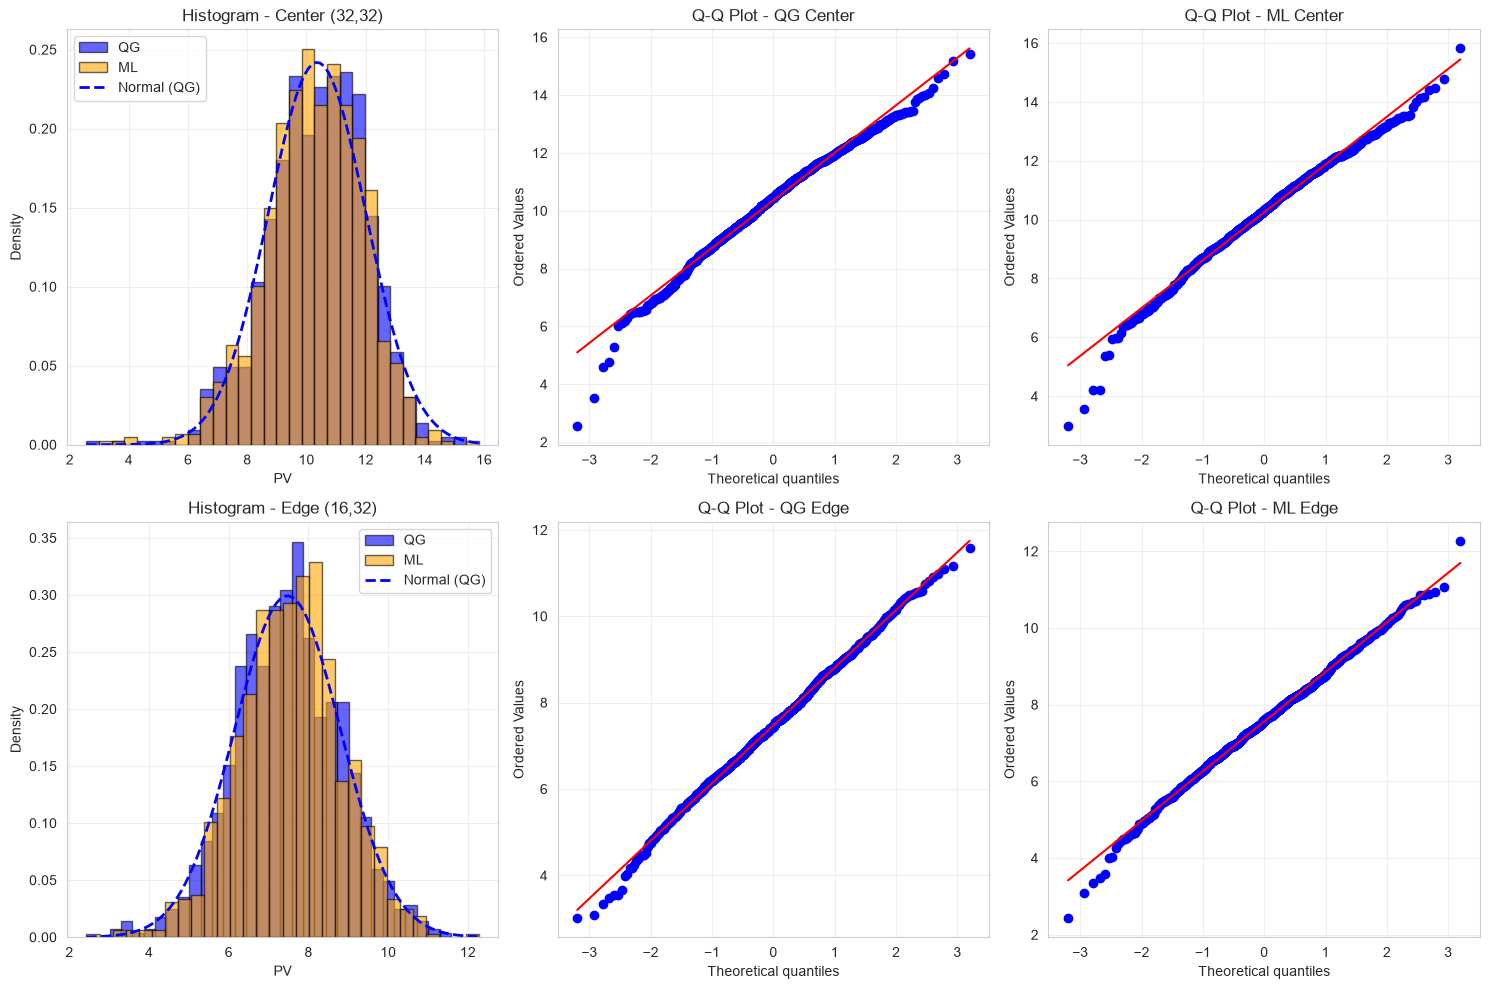

✓ Saved: pv_distributions_detailed.png


In [7]:
# Plot distributions at 2 representative points
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Point 1: Center (typically smoother)
y1, x1 = 32, 32
# Point 2: Edge (more likely non-Gaussian)
y2, x2 = 16, 32

for idx, (y, x, title_suffix) in enumerate([(y1, x1, 'Center'), (y2, x2, 'Edge')]):
    # QG Model - Histogram
    ax = axes[idx, 0]
    qg_vals = pv_qg[:, 0, y, x]
    ml_vals = pv_ml[:, 0, y, x]
    
    ax.hist(qg_vals, bins=30, density=True, alpha=0.6, label='QG', color='blue', edgecolor='black')
    ax.hist(ml_vals, bins=30, density=True, alpha=0.6, label='ML', color='orange', edgecolor='black')
    
    # Add theoretical normal distribution
    x_range = np.linspace(min(qg_vals.min(), ml_vals.min()), 
                          max(qg_vals.max(), ml_vals.max()), 100)
    mean_qg, std_qg = np.mean(qg_vals), np.std(qg_vals)
    ax.plot(x_range, stats.norm.pdf(x_range, mean_qg, std_qg), 
            'b--', linewidth=2, label='Normal (QG)')
    
    ax.set_xlabel('PV')
    ax.set_ylabel('Density')
    ax.set_title(f'Histogram - {title_suffix} ({y},{x})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Q-Q plots
    for model_idx, (vals, label, color) in enumerate([(qg_vals, 'QG', 'blue'), 
                                                        (ml_vals, 'ML', 'orange')]):
        ax = axes[idx, 1 + model_idx]
        stats.probplot(vals, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot - {label} {title_suffix}')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pv_distributions_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: pv_distributions_detailed.png")

## 7. Analysis Using Nearby Points (Window-Averaged)

ANALYSIS WITH NEARBY POINTS (3x3 window = 9 points)

Center (32,32) - 3x3 window:
  QG  - Shapiro p-value: 0.003261, Skew: -0.2436, Kurt: 0.5174
  ML  - Shapiro p-value: 0.015389, Skew: -0.2052, Kurt: 0.4715

Edge (16,32) - 3x3 window:
  QG  - Shapiro p-value: 0.005443, Skew: -0.1318, Kurt: 0.5266
  ML  - Shapiro p-value: 0.001053, Skew: -0.1700, Kurt: 0.5820

Edge (32,16) - 3x3 window:
  QG  - Shapiro p-value: 0.000234, Skew: -0.2241, Kurt: 0.4836
  ML  - Shapiro p-value: 0.000011, Skew: -0.2973, Kurt: 0.5084

Corner (48,48) - 3x3 window:
  QG  - Shapiro p-value: 0.000018, Skew: -0.3425, Kurt: 0.0117
  ML  - Shapiro p-value: 0.000017, Skew: -0.3420, Kurt: 0.0018


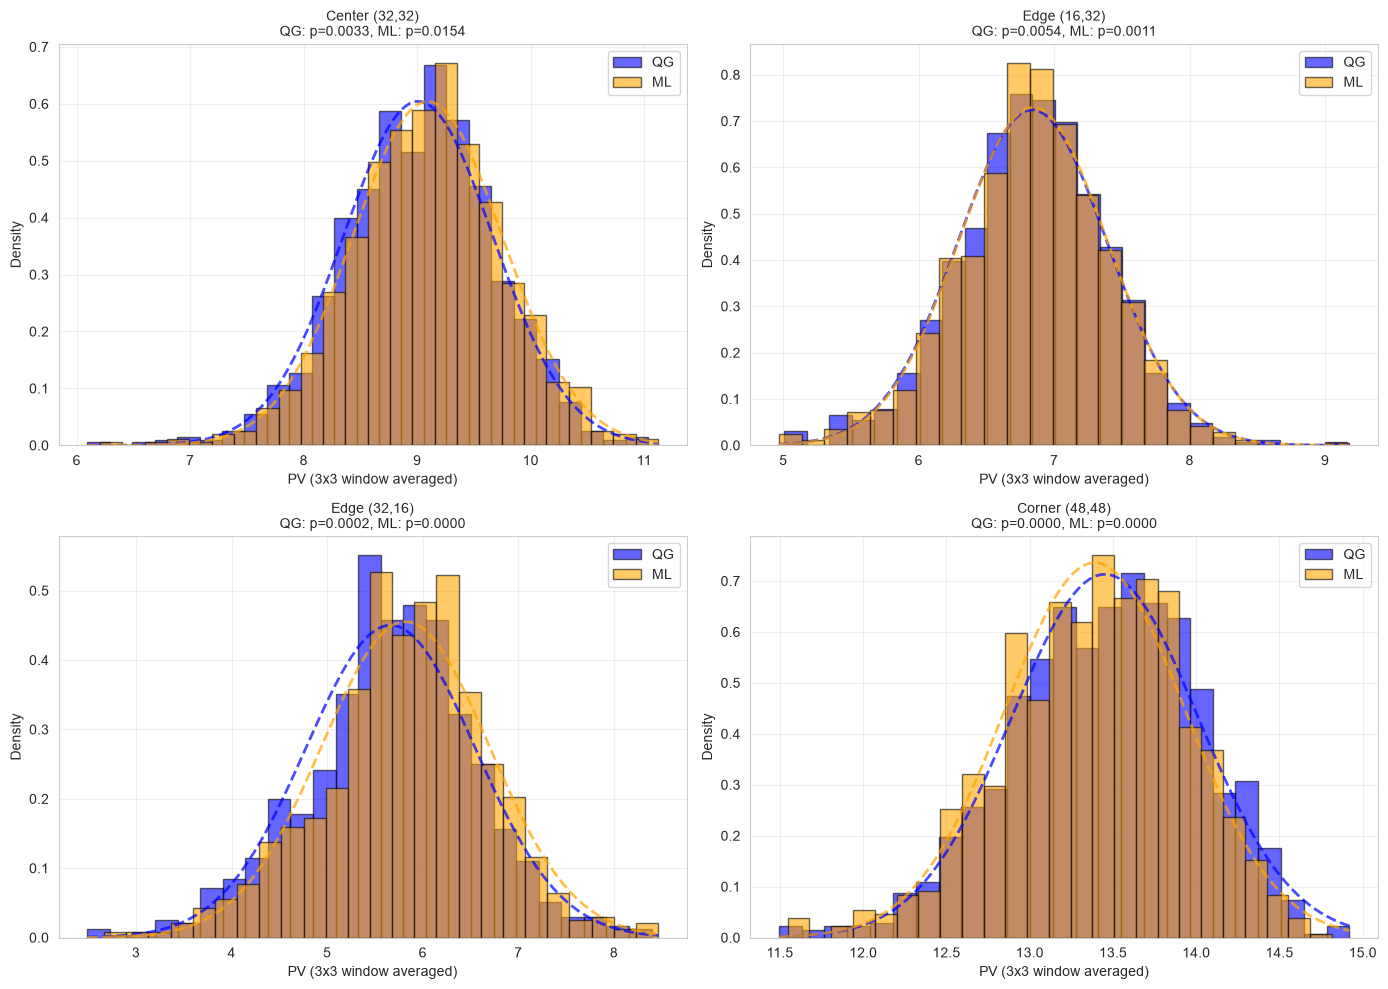


✓ Saved: pv_distributions_windowed.png


In [8]:
# Analyze points with window averaging
print("=" * 80)
print("ANALYSIS WITH NEARBY POINTS (3x3 window = 9 points)")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

window_size = 1  # 3x3 window

# Test points
test_points = [
    (32, 32, 'Center', 0),
    (16, 32, 'Edge', 1),
    (32, 16, 'Edge', 2),
    (48, 48, 'Corner', 3),
]

for y, x, location, plot_idx in test_points:
    res_qg = analyze_normality(pv_qg, layer=0, y=y, x=x, window_size=window_size)
    res_ml = analyze_normality(pv_ml, layer=0, y=y, x=x, window_size=window_size)
    
    ax = axes.flat[plot_idx]
    
    # Comparative histograms
    ax.hist(res_qg['values'], bins=25, density=True, alpha=0.6, label='QG', 
            color='blue', edgecolor='black')
    ax.hist(res_ml['values'], bins=25, density=True, alpha=0.6, label='ML', 
            color='orange', edgecolor='black')
    
    # Theoretical normals
    x_range = np.linspace(min(res_qg['values'].min(), res_ml['values'].min()),
                          max(res_qg['values'].max(), res_ml['values'].max()), 100)
    ax.plot(x_range, stats.norm.pdf(x_range, res_qg['mean'], res_qg['std']), 
            'b--', linewidth=2, alpha=0.7)
    ax.plot(x_range, stats.norm.pdf(x_range, res_ml['mean'], res_ml['std']), 
            'orange', linestyle='--', linewidth=2, alpha=0.7)
    
    title = f'{location} ({y},{x})\n'
    title += f'QG: p={res_qg["shapiro_p"]:.4f}, ML: p={res_ml["shapiro_p"]:.4f}'
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PV (3x3 window averaged)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"\n{location} ({y},{x}) - 3x3 window:")
    print(f"  QG  - Shapiro p-value: {res_qg['shapiro_p']:.6f}, Skew: {res_qg['skew']:.4f}, Kurt: {res_qg['kurtosis']:.4f}")
    print(f"  ML  - Shapiro p-value: {res_ml['shapiro_p']:.6f}, Skew: {res_ml['skew']:.4f}, Kurt: {res_ml['kurtosis']:.4f}")

plt.tight_layout()
plt.savefig('pv_distributions_windowed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: pv_distributions_windowed.png")

## 8. Spatial Analysis - Normality Map Across Grid

Computing normality map for entire grid...
This may take ~30 seconds...
  Processing row 60/64...
✓ Calculation completed


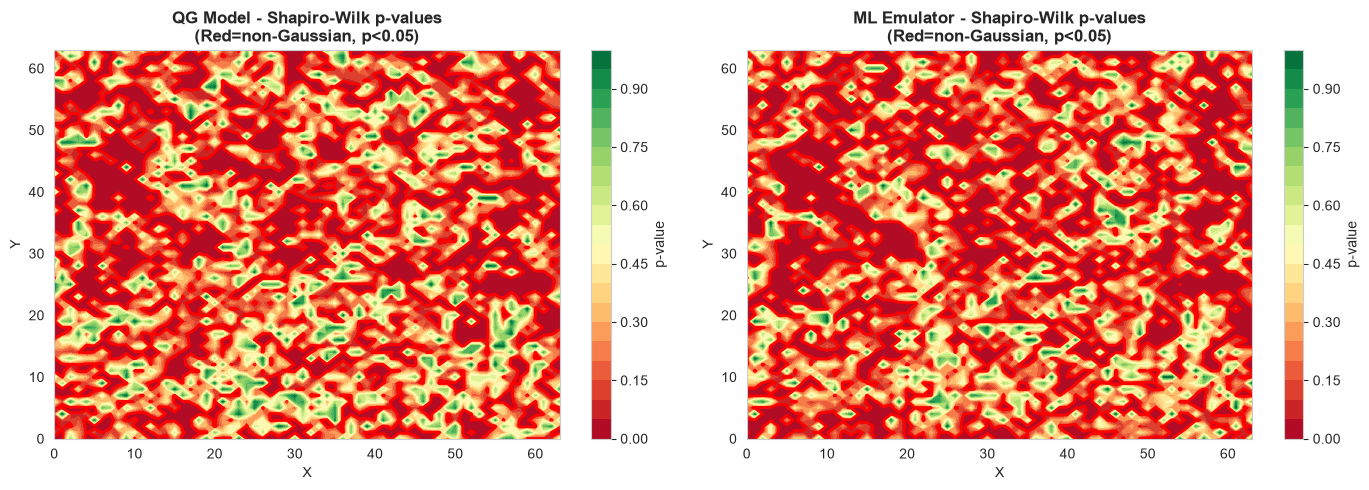

✓ Saved: pv_normality_map.png

Points with non-Gaussian distribution (p < 0.05):
  QG Model: 1959/4096 (47.8%)
  ML Emulator: 2122/4096 (51.8%)


In [9]:
# Calculate p-value map for entire grid (may take a moment)
print("Computing normality map for entire grid...")
print("This may take ~30 seconds...")

ny, nx = pv_qg.shape[2], pv_qg.shape[3]
p_values_qg = np.zeros((ny, nx))
p_values_ml = np.zeros((ny, nx))

# Calculate each point
for j in range(ny):
    if j % 10 == 0:
        print(f"  Processing row {j}/{ny}...", end='\r')
    for i in range(nx):
        _, p_qg = stats.shapiro(pv_qg[:, 0, j, i])
        _, p_ml = stats.shapiro(pv_ml[:, 0, j, i])
        p_values_qg[j, i] = p_qg
        p_values_ml[j, i] = p_ml

print(f"\n✓ Calculation completed")

# Visualize maps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QG Model
im1 = axes[0].contourf(p_values_qg, levels=20, cmap='RdYlGn')
axes[0].contour(p_values_qg, levels=[0.05], colors='red', linewidths=2)
axes[0].set_title('QG Model - Shapiro-Wilk p-values\n(Red=non-Gaussian, p<0.05)', fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('p-value')

# ML Emulator
im2 = axes[1].contourf(p_values_ml, levels=20, cmap='RdYlGn')
axes[1].contour(p_values_ml, levels=[0.05], colors='red', linewidths=2)
axes[1].set_title('ML Emulator - Shapiro-Wilk p-values\n(Red=non-Gaussian, p<0.05)', fontweight='bold')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('p-value')

plt.tight_layout()
plt.savefig('pv_normality_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: pv_normality_map.png")

# Statistics
n_non_gaussian_qg = np.sum(p_values_qg < 0.05)
n_non_gaussian_ml = np.sum(p_values_ml < 0.05)
print(f"\nPoints with non-Gaussian distribution (p < 0.05):")
print(f"  QG Model: {n_non_gaussian_qg}/{ny*nx} ({100*n_non_gaussian_qg/(ny*nx):.1f}%)")
print(f"  ML Emulator: {n_non_gaussian_ml}/{ny*nx} ({100*n_non_gaussian_ml/(ny*nx):.1f}%)")

## 9. Summary and Next Steps

### Key Findings:

1. **Gaussianity**: Compare what percentage of points have Gaussian vs non-Gaussian distributions
2. **Localization**: Where do non-Gaussian points appear? (Near gradients?)
3. **ML vs QG Differences**: Does the ML emulator accurately reproduce non-Gaussian characteristics?
4. **Window Effect**: Does averaging nearby points improve or worsen Gaussianity?

### Next Steps:

1. Identify regions with strong PV gradients and correlate with non-Gaussianity
2. Analyze the second layer (layer 1) if relevant
3. Investigate other variables (relative vorticity, etc.)
4. Compare temporal evolution if necessary